# Import and Define Functions

In [6]:
%pip install pulp
# !pip install pandas numpy matplotlib seaborn requests scikit-learn scipy pulp optuna optunahub tqdm pytz ipykernel
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import pulp

Note: you may need to restart the kernel to use updated packages.


In [7]:
def get_fpl_gameweek_data(fpl_id):
    """Fetches FPL history data and processes gameweek information.

    Args:
        fpl_id: The Fantasy Premier League ID.

    Returns:
        A pandas DataFrame containing processed gameweek data.
    """
    # Fetch static data (events)
    url_static = "https://fantasy.premierleague.com/api/bootstrap-static/"
    response_static = requests.get(url_static)
    response_static.raise_for_status()
    data_static = response_static.json()

    events_df = pd.DataFrame(data_static['events'])

    def extract_chip_plays(chip_list):
        chips = {}
        if isinstance(chip_list, list):
            for chip_info in chip_list:
                chips[chip_info['chip_name'] + "_played"] = chip_info['num_played']
        return chips

    chip_plays_df = events_df['chip_plays'].apply(extract_chip_plays).apply(pd.Series)
    events_df = pd.concat([events_df, chip_plays_df], axis=1)

    # Fetch user's history data
    url_history = f"https://fantasy.premierleague.com/api/entry/{fpl_id}/history"
    response_history = requests.get(url_history)
    response_history.raise_for_status()
    data_history = response_history.json()

    my_performance_df = pd.DataFrame(data_history['current'])

    # Check if 'chips' list is not empty before creating DataFrame
    if data_history.get('chips') and isinstance(data_history['chips'], list) and data_history['chips']:
        my_chips_df = pd.DataFrame(data_history['chips'])[['event', 'name']].rename(columns={'name': 'used_chip_name'})
    else:
        # Create an empty DataFrame with the expected columns if no chips are used
        my_chips_df = pd.DataFrame(columns=['event', 'used_chip_name'])


    my_performance_df = pd.merge(my_performance_df, my_chips_df, left_on='event', right_on='event', how='left')
    my_performance_df.columns = ["my_" + col for col in my_performance_df.columns]


    # Join dataframes on event/my_event
    fpl_gameweeks = pd.merge(events_df, my_performance_df, left_on='id', right_on='my_event', how='left')

    # Set relevant columns to NaN if gameweek is not finished
    unfinished_mask = fpl_gameweeks['finished'] == False
    fpl_gameweeks.loc[unfinished_mask, ['average_entry_score', 'highest_score', 'ranked_count','my_points']] = pd.NA


    fpl_gameweeks['my_overall_percentile_rank'] = round(1 - (fpl_gameweeks['my_overall_rank'] / fpl_gameweeks['ranked_count']),2)*100
    fpl_gameweeks['my_week_percentile_rank'] = round(1 - (fpl_gameweeks['my_rank'] / fpl_gameweeks['ranked_count']),2)*100

    return fpl_gameweeks[[
        'id', 'name', 'deadline_time', 'average_entry_score',
       'finished', 'data_checked', 'highest_score',
       'is_previous', 'is_current', 'is_next',
       'ranked_count', 'most_selected',
       'transfers_made', 'most_captained', 'most_vice_captained',
       'bboost_played', '3xc_played', 'freehit_played', 'wildcard_played',
       'my_total_points', 'my_rank',
       'my_overall_rank','my_overall_percentile_rank','my_points', 'my_week_percentile_rank', 'my_bank', 'my_value',
       'my_event_transfers', 'my_event_transfers_cost', 'my_points_on_bench','my_used_chip_name'
       ]].rename(columns={
        'id': 'gameweek_id',
        'my_points': 'my_week_points',})

In [8]:
def plot_fpl_visuals(fpl_id):
    """
    Create 2 visualizations from FPL gameweeks dataframe:

    Chart 1: My Weekly Points vs Average & Highest
        - y-axis fixed 0–200
        - Show all GWs on x-axis
        - Different font sizes for annotations
        - Legend at bottom center

    Chart 2: My Overall Percentile Rank vs Ranked Count
        - Bars = ranked_count (labels in Millions on top)
        - Percentile rank as line (secondary y-axis 0–100)
    """
    # --- Get gameweek data ---
    df = get_fpl_gameweek_data(fpl_id)
    df = df.sort_values('gameweek_id') # Remove filtering for finished gameweeks

    # --- Build full GW index ---
    max_gw = 38 # Always show all 38 gameweeks
    all_gws = pd.RangeIndex(1, max_gw + 1)
    df = df.set_index('gameweek_id').reindex(all_gws).reset_index()
    df.rename(columns={'index': 'gameweek_id'}, inplace=True)

    # Calculate first and last finished gameweeks once
    first_gw = df['gameweek_id'].min() if not df.empty else None
    finished_mask = df['finished'] == True
    last_gw = df.loc[finished_mask,'gameweek_id'].max() if not df.loc[finished_mask].empty else None
    current_mask = df['is_current'] == True
    current_gw = df.loc[current_mask,'gameweek_id'].max() if not df.loc[current_mask].empty else None


    # --- Create figure with 2 subplots ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18,9))

    # ================= Chart 1: My points vs avg/highest =================
    plot_df = df.melt(
        id_vars=["gameweek_id", "my_week_percentile_rank", "my_used_chip_name"],
        value_vars=["my_week_points","average_entry_score","highest_score"],
        var_name="metric", value_name="points"
    )

    sns.lineplot(
        data=plot_df, x="gameweek_id", y="points", hue="metric",
        style="metric", markers=True, linewidth=3,
        dashes={"my_week_points": "",
                "average_entry_score": (4,2),
                "highest_score": (4,2)}, ax=ax1
    )

    # Annotate points with values - first and latest gameweek, percentile every week
    if first_gw is not None and last_gw is not None:
        for i, row in df.dropna(subset=['my_week_points']).iterrows():
            # Annotate points and percentile for first and last gameweek
            if row['gameweek_id'] == first_gw or row['gameweek_id'] == current_gw: #
                ax1.text(row['gameweek_id'], row['my_week_points']+3,
                         f"{int(row['my_week_points'])}pts.\n({'' if pd.isna(row['my_week_percentile_rank']) else int(row['my_week_percentile_rank'])}%)",
                         ha='center', fontsize=12, weight='bold', color='#1f77b4')
            # Annotate only percentile for other gameweeks
            elif row['gameweek_id'] != first_gw and row['gameweek_id'] != current_gw: #
                 ax1.text(row['gameweek_id'], row['my_week_points'] +3,
                         f"{int(row['my_week_points'])}\n({'' if pd.isna(row['my_week_percentile_rank']) else int(row['my_week_percentile_rank'])}%)",
                         ha='center', fontsize=10,weight='bold', color='#1f77b4')


        for i, row in df.dropna(subset=['average_entry_score']).iterrows():
            if row['gameweek_id'] == first_gw or row['gameweek_id'] == last_gw:
                 ax1.text(row['gameweek_id'], row['average_entry_score']-5,
                         f"{int(row['average_entry_score'])}",
                         ha='center', fontsize=12, color='orange')

        for i, row in df.dropna(subset=['highest_score']).iterrows():
            if row['gameweek_id'] == first_gw or row['gameweek_id'] == last_gw:
                 ax1.text(row['gameweek_id'], row['highest_score']+5,
                         f"{int(row['highest_score'])}",
                         ha='center', fontsize=12, color='green')

    # Add markers and text for used chips on chart 1
    for i, row in df.dropna(subset=['my_week_points', 'my_used_chip_name']).iterrows():
        ax1.plot(row['gameweek_id'], row['my_week_points'], 'ro', markersize=8)
        ax1.text(row['gameweek_id'], row['my_week_points'] - 10, row['my_used_chip_name'],
                 ha='center', fontsize=10, color='red')


    ax1.set_title("My Weekly Points vs Average & Highest", fontsize=16, weight='bold')
    ax1.set_xlabel("Gameweek")
    ax1.set_ylabel("Points")
    ax1.set_xlim(0, max_gw+1)
    ax1.set_ylim(0, 200)
    ax1.set_xticks(range(1, max_gw+1))
    ax1.legend(title="", loc="upper center", bbox_to_anchor=(0.5,-0.12), ncol=3)
    ax1.grid(False)


    # ================= Chart 2: Percentile vs ranked count =================
    bars = ax2.bar(df['gameweek_id'], df['ranked_count'], color="lightgray", alpha=0.7)

    # Add millions notation on top of bars for first and latest gameweek
    if first_gw is not None and last_gw is not None:
        for bar, val, gw in zip(bars, df['ranked_count'], df['gameweek_id']):
            if pd.notna(val) and (gw == first_gw or gw == last_gw):
                ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02*bar.get_height(),
                         f"{val/1e6:.1f}M", ha='center', va='bottom', fontsize=12, color="black")


    ax2.set_ylabel("")
    ax2.set_yticks([])
    ax2.set_ylim(0, df['ranked_count'].max()*1.15 if not df['ranked_count'].empty else 1) # Handle empty df

    # Secondary axis for percentile rank
    ax3 = ax2.twinx()
    sns.lineplot(
        data=df, x="gameweek_id", y="my_overall_percentile_rank",
        marker="o", color='#1f77b4', linewidth=3, ax=ax3
    )

    # Annotate percentile rank - first and latest gameweek, total points every week
    if first_gw is not None and last_gw is not None:
        for i, row in df.dropna(subset=['my_overall_percentile_rank']).iterrows():
             # Annotate total points and percentile for first and last gameweek
             if row['gameweek_id'] == first_gw or row['gameweek_id'] == last_gw: #
                ax3.text(row['gameweek_id'], row['my_overall_percentile_rank']+2,
                         f"{int(row['my_total_points'])}pts.\n({int(row['my_overall_percentile_rank'])}%)",
                         ha='center', fontsize=12, weight='bold', color='#1f77b4')
            # Annotate only total points for other gameweeks
             elif row['gameweek_id'] != first_gw and row['gameweek_id'] != last_gw : #
                 ax3.text(row['gameweek_id'], row['my_overall_percentile_rank']-5, # Adjusted dy to avoid overlap
                          f"{int(row['my_total_points'])}",
                          ha='center', fontsize=10, weight='bold', color='#1f77b4')


    # Add markers and text for used chips on chart 2
    for i, row in df.dropna(subset=['my_overall_percentile_rank', 'my_used_chip_name']).iterrows():
        ax3.plot(row['gameweek_id'], row['my_overall_percentile_rank'], 'ro', markersize=8)
        ax3.text(row['gameweek_id'], row['my_overall_percentile_rank'] - 5, row['my_used_chip_name'],
                 ha='center', fontsize=10, color='red')


    ax3.set_ylabel("Overall Percentile Rank")
    ax3.set_ylim(0, 115)
    ax3.set_yticks(range(0, 101, 10))
    ax3.yaxis.set_major_formatter(mtick.PercentFormatter())

    ax2.set_title("My Overall Percentile Rank vs Ranked Count", fontsize=16, weight='bold')
    ax2.set_xlabel("Gameweek")
    ax2.set_xlim(0, max_gw+1)
    ax2.set_xticks(range(1, max_gw+1))
    ax2.grid(False)
    ax3.grid(False)

    # Adjust layout
    fig.tight_layout()
    plt.show()

In [9]:
def get_pos_constraint_df():
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    pos_df = pd.DataFrame(data['element_types'])

    return pos_df[
        ['id',
         'singular_name_short',
         'squad_select',
         'squad_min_play',
         'squad_max_play',
       ]
        ]

In [10]:
def get_current_players_df():
    """
    Fetches current player data from the FPL API and creates a DataFrame.

    Returns:
        pd.DataFrame: DataFrame containing current player information.
    """
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()
    # Create base dataframes
    elements_df = pd.DataFrame(data['elements'])
    teams_df = pd.DataFrame(data['teams'])
    pos_df = pd.DataFrame(data['element_types'])

    if 'now_cost' in elements_df.columns:
      elements_df['now_cost'] = elements_df['now_cost'] / 10.0

    # Position & team mapping
    pos_map = pos_df.set_index('id')['singular_name_short']
    team_map = teams_df.set_index('id')['name']
    elements_df['position'] = elements_df['element_type'].map(pos_map)
    elements_df['team_name'] = elements_df['team'].map(team_map)

    return elements_df

In [11]:
def create_optimal_fpl_team(budget = 100):
    """
    Selects an optimal fantasy football team (11 starters, 4 bench) based on
    player data using linear programming, visualizes team points by position,
    analyzes team cost, and returns the starter and bench DataFrames.

    Args:
        budget: The maximum allowed total cost for the squad.

    Returns:
        A tuple containing two pandas DataFrames:
        - starter_df_full: DataFrame for the starting 11 players.
        - bench_df_full: DataFrame for the 4 bench players.
    """
    player_df = get_current_players_df()
    # Linear Programming Optimization
    player_ids = sorted(player_df['id'].unique())
    points = player_df.set_index(['id'])['total_points'].to_dict()
    costs = player_df.set_index(['id'])['now_cost'].to_dict()
    positions = player_df.set_index(['id'])['position'].to_dict()
    teams = player_df.set_index(['id'])['team_name'].to_dict()
    names = player_df.set_index(['id'])['web_name'].to_dict()

    prob = pulp.LpProblem("FPL_Dreamteam", pulp.LpMaximize)

    squad = pulp.LpVariable.dicts("Squad", (player_ids), cat='Binary')
    starters = pulp.LpVariable.dicts("Starter", (player_ids), cat='Binary')

    # Objective function: Maximize total points (including bench points at 5%)
    total_score = pulp.lpSum(starters[p] * points.get(p, 0) for p in player_ids) + pulp.lpSum(
                    (squad[p] - starters[p]) * points.get(p, 0) * 0.05
                    for p in player_ids
                )
    prob += total_score, "Total Score"

    # Constraints
    total_cost = pulp.lpSum(squad[p] * costs.get(p, 0) for p in player_ids)
    prob += total_cost <= budget, "Total Cost Constraint"

    prob += pulp.lpSum(starters[p] for p in player_ids) == 11, "Number of Starters"
    prob += pulp.lpSum(squad[p] for p in player_ids) == 15, "Squad Size"

    # Position constraints for squad and starters
    pos_constraint = get_pos_constraint_df()
    for _, row in pos_constraint.iterrows():
        pos = row['singular_name_short']
        min_players = row['squad_min_play']
        max_players = row['squad_max_play']
        squad_select = row['squad_select']

        prob += pulp.lpSum(squad[p] for p in player_ids if positions.get(p) == pos) == squad_select, f"Squad {pos} Constraint"

        if pd.notna(min_players):
            prob += pulp.lpSum(starters[p] for p in player_ids if positions.get(p) == pos) >= min_players, f"Starter Min {pos} Constraint"
        if pd.notna(max_players):
            prob += pulp.lpSum(starters[p] for p in player_ids if positions.get(p) == pos) <= max_players, f"Starter Max {pos} Constraint"

    # Team constraints
    for team in player_df['team_name'].unique():
        prob += pulp.lpSum(squad[p] for p in player_ids if teams.get(p) == team) <= 3, f"Max 3 players from {team}"

    # Ensure starters are also in the squad
    for p in player_ids:
        prob += starters[p] <= squad[p], f"Starter {p} must be in Squad"

    # Solve the problem
    prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=180))

    # Team Selection and Sorting
    starter_ids = [p for p in player_ids if pulp.value(starters[p]) == 1]
    bench_ids = [p for p in player_ids if pulp.value(squad[p]) == 1 and pulp.value(starters[p]) == 0]

    starter_df_full = player_df[player_df['id'].isin(starter_ids)].copy()
    bench_df_full = player_df[player_df['id'].isin(bench_ids)].copy()

    position_order = ['GKP', 'DEF', 'MID', 'FWD']
    starter_df_full['position'] = pd.Categorical(starter_df_full['position'], categories=position_order, ordered=True)
    bench_df_full['position'] = pd.Categorical(bench_df_full['position'], categories=position_order, ordered=True)

    starter_df_full = starter_df_full.sort_values(by=['position', 'total_points'], ascending=[True, False])
    bench_df_full = bench_df_full.sort_values(by=['position', 'total_points'], ascending=[True, False])

    # Visualization
    print(f"")
    print(20*"#"+f" Starter "+20*"#")
    print(f"")
    print(starter_df_full[
        [
            'id' ,
            'web_name' ,
            'now_cost' ,
            'position' ,
            'team_name' ,
            'selected_by_percent',
            'total_points',
            'points_per_game' ,
        ]
    ].to_string(index = False))
    print(f"")
    print(20*"#"+f" Bench "+20*"#")
    print(f"")
    print(bench_df_full[
        [
            'id' ,
            'web_name' ,
            'now_cost' ,
            'position' ,
            'team_name' ,
            'selected_by_percent',
            'total_points',
            'points_per_game' ,
        ]
    ].to_string(index = False))

    # Cost Analysis
    starter_cost = starter_df_full['now_cost'].sum()
    bench_cost = bench_df_full['now_cost'].sum()
    total_squad_cost = starter_cost + bench_cost


    print(f"")
    print(f"Total cost of the entire squad: £{total_squad_cost:.2f}")
    print(f"Total cost of the starting team: £{starter_cost:.2f}")
    print(f"Total cost of the bench: £{bench_cost:.2f}")

    if total_squad_cost <= budget:
        print(f"The total squad cost (£{total_squad_cost:.2f}) is within the budget (£{budget:.2f}).")
    else:
        print(f"The total squad cost (£{total_squad_cost:.2f}) exceeds the budget (£{budget:.2f}).")

    return

# Configuration & Run

## Manager Score Progession

In [12]:
MY_FPL_ID = 6025459

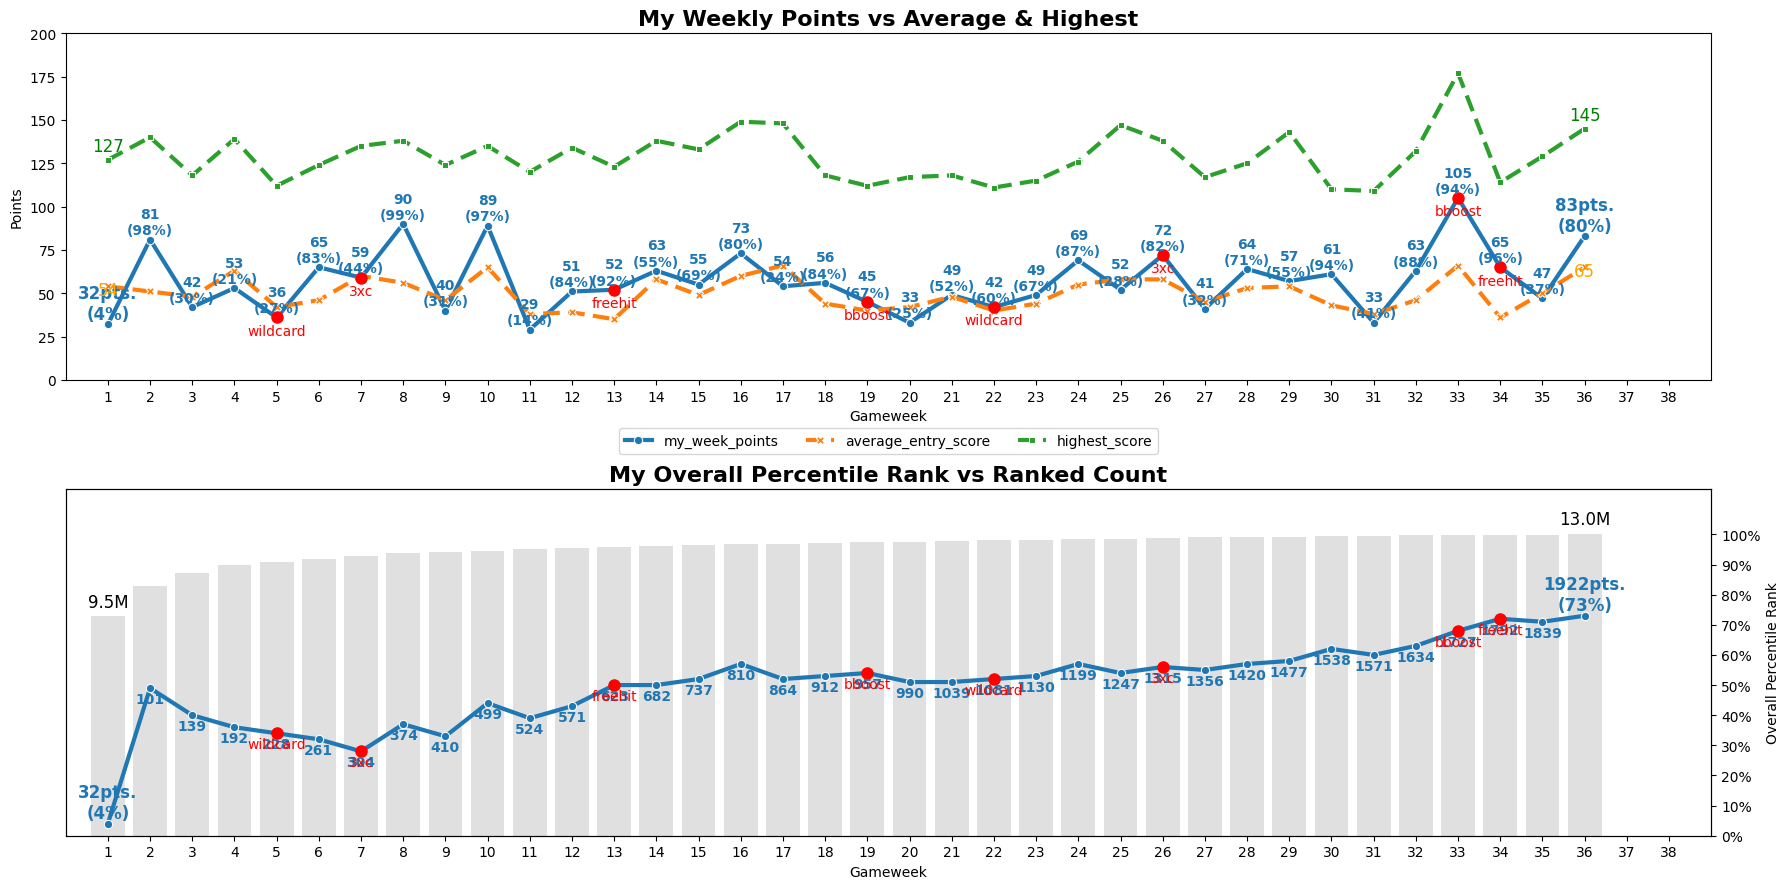

In [13]:
plot_fpl_visuals(MY_FPL_ID)

## Get Team of The Season So Far

In [ ]:
create_optimal_fpl_team(budget = 105)


#################### Starter ####################

 id    web_name  now_cost position     team_name selected_by_percent  total_points points_per_game
  1        Raya       6.0      GKP       Arsenal                34.0           141             4.1
  5     Gabriel       7.1      DEF       Arsenal                43.3           185             6.6
260       Guéhi       5.1      DEF      Man City                32.8           158             5.1
373      Virgil       6.2      DEF     Liverpool                33.7           156             4.6
449 B.Fernandes      10.4      MID       Man Utd                46.8           199             6.6
 82     Semenyo       8.2      MID      Man City                51.3           181             5.7
 21        Rice       7.2      MID       Arsenal                24.4           171             5.2
515 Gibbs-White       7.6      MID Nott'm Forest                10.1           168             4.9
430     Haaland      14.5      FWD      Man City         

# Debug

In [14]:
get_fpl_gameweek_data(6025459)

,gameweek_id,name,deadline_time,average_entry_score,finished,data_checked,highest_score,is_previous,is_current,is_next,...,my_overall_rank,my_overall_percentile_rank,my_week_points,my_week_percentile_rank,my_bank,my_value,my_event_transfers,my_event_transfers_cost,my_points_on_bench,my_used_chip_name
0,1,Gameweek 1,2025-08-15T17:30:00Z,54.0,True,True,127.0,False,False,False,...,9132911.0,4.0,32.0,4.0,0.0,1000.0,0.0,0.0,13.0,NaN
1,2,Gameweek 2,2025-08-22T17:30:00Z,51.0,True,True,140.0,False,False,False,...,5532091.0,49.0,81.0,98.0,20.0,1001.0,4.0,12.0,13.0,NaN
2,3,Gameweek 3,2025-08-30T10:00:00Z,48.0,True,True,118.0,False,False,False,...,6731890.0,40.0,42.0,30.0,31.0,1005.0,2.0,4.0,10.0,NaN
3,4,Gameweek 4,2025-09-13T10:00:00Z,63.0,True,True,139.0,False,False,False,...,7396903.0,36.0,53.0,21.0,41.0,1009.0,1.0,0.0,9.0,NaN
4,5,Gameweek 5,2025-09-20T10:00:00Z,42.0,True,True,112.0,False,False,False,...,7733289.0,34.0,36.0,27.0,0.0,1003.0,0.0,0.0,5.0,wildcard
5,6,Gameweek 6,2025-09-27T10:00:00Z,46.0,True,True,124.0,False,False,False,...,8150339.0,32.0,65.0,83.0,0.0,1006.0,9.0,32.0,3.0,NaN
6,7,Gameweek 7,2025-10-03T17:30:00Z,60.0,True,True,135.0,False,False,False,...,8722351.0,28.0,59.0,44.0,8.0,1009.0,5.0,16.0,11.0,3xc
7,8,Gameweek 8,2025-10-18T10:00:00Z,56.0,True,True,138.0,False,False,False,...,7610611.0,37.0,90.0,99.0,19.0,1013.0,6.0,20.0,15.0,NaN
8,9,Gameweek 9,2025-10-24T17:30:00Z,46.0,True,True,124.0,False,False,False,...,8128842.0,33.0,40.0,31.0,31.0,1018.0,2.0,4.0,6.0,NaN
9,10,Gameweek 10,2025-11-01T13:30:00Z,65.0,True,True,135.0,False,False,False,...,6819539.0,44.0,89.0,97.0,19.0,1022.0,1.0,0.0,21.0,NaN
